In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r"D:\Personal\Youtube_content\amazon_products_sales_data_cleaned.csv")
df.head(2)

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

In [13]:
len(df)

42675

In [15]:
df.isnull().sum()*100 / len(df)

product_title            0.000000
product_rating           2.399531
total_reviews            2.399531
purchased_last_month    24.630346
discounted_price         4.831869
original_price           4.831869
is_best_seller           0.000000
is_sponsored             0.000000
has_coupon               0.000000
buy_box_availability    34.336262
delivery_date           28.079672
sustainability_tags     92.014060
product_image_url        0.000000
product_page_url         4.848272
data_collected_at        0.000000
product_category         0.000000
discount_percentage      4.831869
dtype: float64

In [17]:
df.duplicated().sum()

0

### Action Items

In [20]:
df.columns

Index(['product_title', 'product_rating', 'total_reviews',
       'purchased_last_month', 'discounted_price', 'original_price',
       'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability',
       'delivery_date', 'sustainability_tags', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category',
       'discount_percentage'],
      dtype='object')

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
product_rating,41651.0,4.399431,0.386997,1.00,4.20,4.50,4.70,5.00
total_reviews,41651.0,3087.106000,13030.460133,1.00,82.00,343.00,1886.00,865598.00
purchased_last_month,32164.0,1293.665278,6318.323574,50.00,100.00,200.00,400.00,100000.00
discounted_price,40613.0,243.227289,473.351545,2.16,29.69,84.99,224.00,5449.00
original_price,40613.0,257.611107,496.633495,2.16,32.99,89.00,229.99,5449.00
discount_percentage,40613.0,6.547151,12.744715,0.00,0.00,0.00,8.49,85.42


In [30]:
num_df = df.select_dtypes(include = "number")
cat_df = df.select_dtypes(exclude = "number")

In [36]:
num_df.isnull().sum()

product_rating           1024
total_reviews            1024
purchased_last_month    10511
discounted_price         2062
original_price           2062
discount_percentage      2062
dtype: int64

In [54]:
num_df['product_rating'].median()

4.5

In [56]:
for column in num_df.columns:
    num_df[column] = num_df[column].fillna(num_df[column].median())

In [58]:
num_df.isnull().sum()

product_rating          0
total_reviews           0
purchased_last_month    0
discounted_price        0
original_price          0
discount_percentage     0
dtype: int64

In [72]:
for column in cat_df:
    mode_value = (cat_df[column].mode().values[0])
    cat_df[column] = cat_df[column].fillna(mode_value)

In [74]:
cat_df.isnull().sum()

product_title           0
is_best_seller          0
is_sponsored            0
has_coupon              0
buy_box_availability    0
delivery_date           0
sustainability_tags     0
product_image_url       0
product_page_url        0
data_collected_at       0
product_category        0
dtype: int64

In [80]:
df = pd.concat([num_df, cat_df], axis = 1)
df.head()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage,product_title,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category
0,4.6,375.0,300.0,89.68,159.00,43.60,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones
1,4.3,2457.0,6000.0,9.99,15.99,37.52,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,Small Business,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops
2,4.6,3044.0,2000.0,314.00,349.00,10.03,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,Small Business,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops
3,4.6,35882.0,10000.0,162.24,162.24,0.00,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",Best Seller,Organic,No Coupon,Add to cart,2025-09-04,Small Business,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones
4,4.8,28988.0,10000.0,72.74,72.74,0.00,Apple AirTag 4 Pack. Keep Track of and find Yo...,No Badge,Organic,No Coupon,Add to cart,2025-09-04,Small Business,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones


In [82]:
df.isnull().sum()

product_rating          0
total_reviews           0
purchased_last_month    0
discounted_price        0
original_price          0
discount_percentage     0
product_title           0
is_best_seller          0
is_sponsored            0
has_coupon              0
buy_box_availability    0
delivery_date           0
sustainability_tags     0
product_image_url       0
product_page_url        0
data_collected_at       0
product_category        0
dtype: int64

In [84]:
df['total_reviews'] = df['total_reviews'].astype(int)
df['purchased_last_month'] = df['purchased_last_month'].astype(int)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   product_rating        42675 non-null  float64       
 1   total_reviews         42675 non-null  int32         
 2   purchased_last_month  42675 non-null  int32         
 3   discounted_price      42675 non-null  float64       
 4   original_price        42675 non-null  float64       
 5   discount_percentage   42675 non-null  float64       
 6   product_title         42675 non-null  object        
 7   is_best_seller        42675 non-null  object        
 8   is_sponsored          42675 non-null  object        
 9   has_coupon            42675 non-null  object        
 10  buy_box_availability  42675 non-null  object        
 11  delivery_date         42675 non-null  datetime64[ns]
 12  sustainability_tags   42675 non-null  object        
 13  product_image_ur

In [88]:
df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors = 'coerce')
df['data_collected_at'] = pd.to_datetime(df['data_collected_at'], errors = 'coerce')

In [92]:
df.drop(['sustainability_tags'], axis = 1, inplace = True)

In [107]:
df.head(2)

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage,product_title,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,product_image_url,product_page_url,data_collected_at,product_category,discounted_amount,estimated_revenue,percantage_band
0,4.6,375,300,89.68,159.00,43.60,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,69.32,26904.0,High
1,4.3,2457,6000,9.99,15.99,37.52,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,6.00,59940.0,Medium discount


### Feature Engineering

In [97]:
df['discounted_amount'] = df['original_price'] - df['discounted_price']

In [101]:
df['estimated_revenue'] = df['discounted_price'] * df['purchased_last_month']

In [105]:
df['percantage_band'] = pd.cut(x = df['discount_percentage'], 
                              bins = [0, 10, 40, 70, 99],
                              labels = ["Less discount", "Medium discount", "High", "very High"])

### Univariate analysis

__categorical column analysis__

In [118]:
df['percantage_band'].value_counts() * 100 / len(df)

percantage_band
Medium discount    18.673697
Less discount       7.163445
High                2.685413
very High           0.325718
Name: count, dtype: float64

### Observations: 

__Numerical column__

In [116]:
df['total_reviews'].describe()

count     42675.000000
mean       3021.260316
std       12880.020115
min           1.000000
25%          84.000000
50%         343.000000
75%        1825.500000
max      865598.000000
Name: total_reviews, dtype: float64

# Bi-variate analysis

### cat vs num

In [136]:
df[['product_category', 'purchased_last_month']].head()

,product_category,purchased_last_month
0,Phones,300
1,Laptops,6000
2,Laptops,2000
3,Phones,10000
4,Phones,10000


In [140]:
df.groupby(['product_category'])['purchased_last_month'].sum().sort_values(ascending = False)

product_category
Power & Batteries      26170250
Other Electronics       4091800
Phones                  3880950
Laptops                 3828250
Cameras                 1050900
TV & Display             967150
Chargers & Cables        879550
Wearables                786850
Storage                  628050
Networking               321850
Speakers                 301950
Printers & Scanners      290450
Headphones               230350
Gaming                   152100
Smart Home               131200
Name: purchased_last_month, dtype: int32

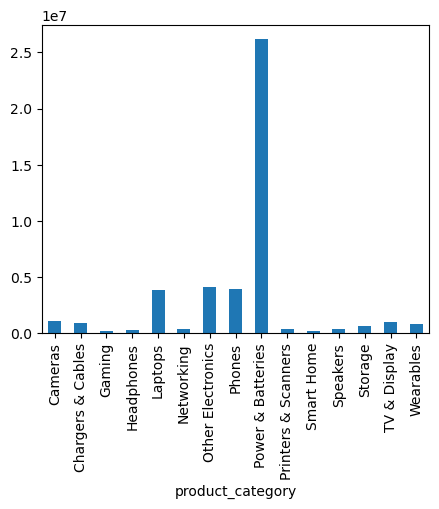

In [144]:
df.groupby(['product_category'])['purchased_last_month'].sum().plot(kind = 'bar', figsize = (5,4))
plt.show()

### cat vs cat

In [147]:
df.columns

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage',
       'product_title', 'is_best_seller', 'is_sponsored', 'has_coupon',
       'buy_box_availability', 'delivery_date', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category',
       'discounted_amount', 'estimated_revenue', 'percantage_band'],
      dtype='object')

In [149]:
df[['product_category', 'is_sponsored']].head()

,product_category,is_sponsored
0,Phones,Sponsored
1,Laptops,Sponsored
2,Laptops,Sponsored
3,Phones,Organic
4,Phones,Organic


In [153]:
pd.crosstab(index = df["is_sponsored"], columns = df["product_category"] )

product_category,Cameras,Chargers & Cables,Gaming,Headphones,Laptops,Networking,Other Electronics,Phones,Power & Batteries,Printers & Scanners,Smart Home,Speakers,Storage,TV & Display,Wearables
is_sponsored,,,,,,,,,,,,,,,
Organic,3109,1573,797,798,8061,837,8568,5190,1339,877,456,1119,1097,1407,436
Sponsored,568,260,12,199,632,233,187,1373,1538,0,9,226,533,1223,18


### Num vs num

In [162]:
df[['product_rating', 'purchased_last_month']].head()

,product_rating,purchased_last_month
0,4.6,300
1,4.3,6000
2,4.6,2000
3,4.6,10000
4,4.8,10000


In [164]:
df[['product_rating', 'purchased_last_month']].corr()

,product_rating,purchased_last_month
product_rating,1.000000,0.134106
purchased_last_month,0.134106,1.000000


### Multi-variate analysis

In [167]:
df.columns

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage',
       'product_title', 'is_best_seller', 'is_sponsored', 'has_coupon',
       'buy_box_availability', 'delivery_date', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category',
       'discounted_amount', 'estimated_revenue', 'percantage_band'],
      dtype='object')

In [175]:
df[['product_category','is_sponsored', 'purchased_last_month']].head(2)

,product_category,is_sponsored,purchased_last_month
0,Phones,Sponsored,300
1,Laptops,Sponsored,6000


In [190]:
pd.pivot_table(df, index = ["product_category"],
                   columns = ["is_sponsored"],
                   values = ["estimated_revenue", "total_reviews"], aggfunc= "median")

estimated_revenue           total_reviews          
is_sponsored                  Organic Sponsored       Organic Sponsored
product_category                                                       
Cameras                       15999.0   59800.0         358.0      30.0
Chargers & Cables              9998.0    7198.0         202.0      30.0
Gaming                        13798.0   61998.0        1110.0   28293.0
Headphones                    11200.0    6249.5         883.0      76.0
Laptops                       19990.0   26378.0         182.0     343.0
Networking                    17997.5   31998.0         328.0      24.0
Other Electronics             10797.5   80198.0         376.0       6.0
Phones                        11876.0   26904.0         925.0    3510.0
Power & Batteries              7648.0  393800.0        2109.0    5207.0
Printers & Scanners            8005.0       NaN         801.0       NaN
Smart Home                    86038.0   79998.0         198.0       2.0
Speakers                      12995.0   35998.0         322.0      45.0
Storage                       15686.0   11998.0         340.0       7.0
TV & Display                  11992.0   17198.0         288.0      29.0
Wearables                      8499.0  296400.0        1320.0   24144.0